Other Colabs

1. [Centrality](https://colab.research.google.com/drive/19EfBQSqsmOrdEKVpAoFWprqmGlWXM5pm?usp=sharing)

In [ ]:
# import pandas as pd

# df=pd.read_csv('300_TRANSCRIPT.csv',delimiter='\t')

In [ ]:
# last_speaker=''
# last_sentence=''
# not_printed=True
# sentences = []
# for i,r in df.iterrows():
#     if r['speaker']==last_speaker:
#         last_sentence += ' '+r['value']
#         not_printed = True
#     else:
#         # print(last_sentence)
#         if last_sentence != '':
#             sentences.append(last_sentence)
#         last_sentence = ''
#         last_sentence = r['value']
#         not_printed = False
# if not_printed:
#     # print(last_sentence)
#     sentences.append(last_sentence)


In [ ]:
# # prompt: I have a list of sentences in the variable sentences. I want to remove all stop words from the strings in the list and also lemmatize all sentences.

# import nltk
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')
# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

# stop_words = set(stopwords.words('english'))
# lemmatizer = WordNetLemmatizer()

# def clean_text(text):
#   words = text.lower().split()
#   words = [lemmatizer.lemmatize(w) for w in words if not w in stop_words]
#   return " ".join(words)

# cleaned_sentences = [clean_text(s) for s in sentences]


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# edges=[]
# for i in range(len(cleaned_sentences)-1):
#   j=i+1
#   for word1 in cleaned_sentences[i].split():
#     for word2 in cleaned_sentences[j].split():
#         edges.append((word1,word2))


In [ ]:
# import networkx as nx
# G=nx.Graph()
# G.add_edges_from(edges)

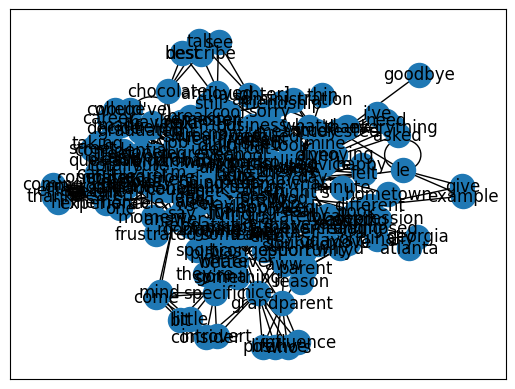

In [ ]:
# nx.draw_networkx(G)

In [ ]:
# file=open('300_edges.csv','w')
# for edge in edges:
#     file.write(edge[0]+','+edge[1]+'\n')
# file.close()

## Matrix Construction

In [ ]:
# ! unzip daic_woz_cleaned.zip

Archive:  daic_woz_cleaned.zip
replace daic_woz_cleaned/463_TRANSCRIPT_cleaned.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [1]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/pataweeprakrankamanant/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/pataweeprakrankamanant/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/pataweeprakrankamanant/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [2]:
import pandas as pd
from nltk.tokenize import MWETokenizer
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()
tokenizer = MWETokenizer()
from itertools import chain
import os
import networkx as nx
import numpy as np
import json 

def lemmatize_text_with_pos(text):
    words = text.lower().split()
    tagged_words = nltk.pos_tag(words)
    lemmatized_words = []
    for word, tag in tagged_words:
        if tag.startswith('N'):  # Noun
            pos = 'n'
        elif tag.startswith('V'):  # Verb
            pos = 'v'
        elif tag.startswith('J'):  # Adjective
            pos = 'a'
        elif tag.startswith('R'):  # Adverb
            pos = 'r'
        else:
            pos = 'n'  # Default to noun if unsure
        lemmatized_words.append(lemmatizer.lemmatize(word, pos=pos))
    return lemmatized_words

def get_matrix(directory, 
                path_dict_idx_json = 'dict_idx.json', 
                path_all_word = 'all_word.txt', 
                path_dir_matrix_out = 'daic_woz_mat_output', 
                ):
    all_words = set()
    for filename in os.listdir(directory):
        if filename.endswith("_TRANSCRIPT_cleaned.csv"):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath, delimiter='\t')
            df = df.drop_duplicates()
            df = df.dropna(subset=['value'])

            last_speaker = ''
            last_sentence = ''
            new_rows = []
            for i, row in df.iterrows():
                if row['speaker'] == last_speaker:
                    last_sentence += ' ' + row['value']
                else:
                    if last_sentence != '':
                        new_rows.append([last_speaker, last_sentence])
                    last_sentence = row['value']
                    last_speaker = row['speaker']
            if last_sentence != '':
                new_rows.append([last_speaker, last_sentence])

            new_df = pd.DataFrame(new_rows, columns=['speaker', 'value'])
            new_df['value'] = new_df['value'].str.replace(r'\b(a|an|the)\b', '', regex=True)
            new_df['tokenized_value'] = new_df['value'].apply(lambda x: ' '.join(tokenizer.tokenize(nltk.word_tokenize(x))))
            new_df['lemmatized_value'] = new_df['tokenized_value'].apply(lemmatize_text_with_pos)
            all_words.update(chain.from_iterable(new_df['lemmatized_value'].values))
    all_words = list(all_words)
    indices = {word:i for i,word in enumerate(all_words)}
    
    # * save 'all_words' to txt
    with open(path_all_word, 'w') as f:
        for line in all_words:
            f.write(f"{line}\n")
    

    # * save 'indices' to json 
    with open(path_dict_idx_json, "w") as outfile: 
        json.dump(indices, outfile)
    
    matrices=[]
    for filename in os.listdir(directory):
        if filename.endswith("_TRANSCRIPT_cleaned.csv"):
            output_matrix = np.zeros((len(all_words),len(all_words)))
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath, delimiter='\t')
            df = df.drop_duplicates()
            df = df.dropna(subset=['value'])
            last_speaker = ''
            last_sentence = ''
            new_rows = []
            for i, row in df.iterrows():
                if row['speaker'] == last_speaker:
                    last_sentence += ' ' + row['value']
                else:
                    if last_sentence != '':
                        new_rows.append([last_speaker, last_sentence])
                    last_sentence = row['value']
                    last_speaker = row['speaker']
            if last_sentence != '':
                new_rows.append([last_speaker, last_sentence])

            new_df = pd.DataFrame(new_rows, columns=['speaker', 'value'])
            new_df['value'] = new_df['value'].str.replace(r'\b(a|an|the)\b', '', regex=True)
            new_df['tokenized_value'] = new_df['value'].apply(lambda x: ' '.join(tokenizer.tokenize(nltk.word_tokenize(x))))
            new_df['lemmatized_value'] = new_df['tokenized_value'].apply(lemmatize_text_with_pos)
            for i in range(len(new_df['lemmatized_value'])-1):
                for word1 in new_df['lemmatized_value'][i]:
                    for word2 in new_df['lemmatized_value'][i+1]:
                        output_matrix[indices[word1],indices[word2]]+=1
            
            if not os.path.exists(path_dir_matrix_out): os.makedirs(path_dir_matrix_out)
            user_id = filename.split('_')[0]
            np.save(os.path.join(path_dir_matrix_out,f'{user_id}_mat'), output_matrix)

            matrices.append(output_matrix)


    return matrices, all_words, indices

matrices,_,_= get_matrix('daic_woz_cleaned/')

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import sys

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
num_epochs = 10
batch_size = 100
learning_rate = 0.001

# Data loading and preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)  # CIFAR-10 has 10 classes

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training the model
def train_model():
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            print('images.shape', images.shape)
            sys.exit()
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            if (i + 1) % 100 == 0:
                print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}')
                running_loss = 0.0

# Test the model
def test_model():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f'Accuracy of the model on the 10,000 test images: {100 * correct / total:.2f}%')

if __name__ == "__main__":
    train_model()
    test_model()

100%|██████████| 170498071/170498071 [00:16<00:00, 10298494.17it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
images.shape torch.Size([100, 3, 32, 32])


SystemExit: 

/Users/pataweeprakrankamanant/anaconda3/envs/maywe3.10/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3516: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)
